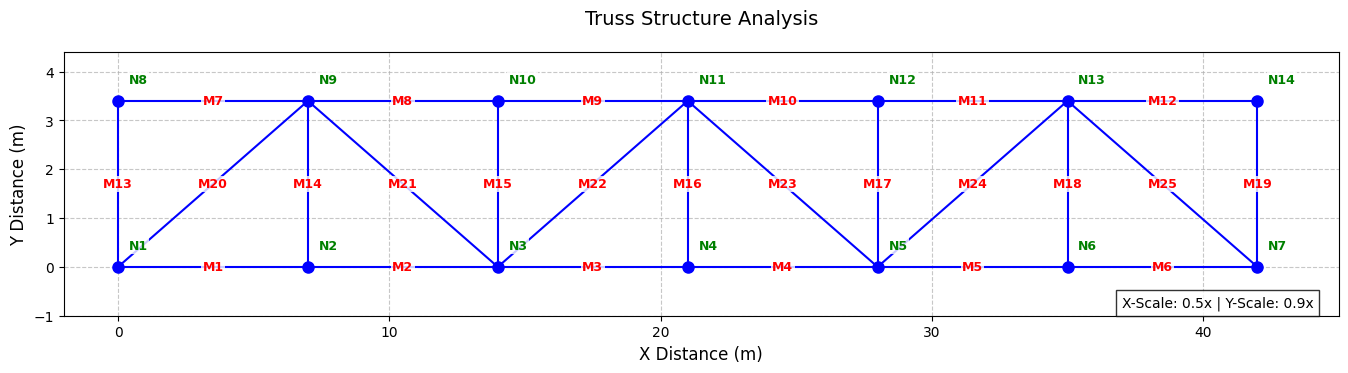

Node 1 defined
Node 2 defined
Node 3 defined
Node 4 defined
Node 5 defined
Node 6 defined
Node 7 defined
Node 8 defined
Node 9 defined
Node 10 defined
Node 11 defined
Node 12 defined
Node 13 defined
Node 14 defined
Element 1 defined
Element 2 defined
Element 3 defined
Element 4 defined
Element 5 defined
Element 6 defined
Element 7 defined
Element 8 defined
Element 9 defined
Element 10 defined
Element 11 defined
Element 12 defined
Element 13 defined
Element 14 defined
Element 15 defined
Element 16 defined
Element 17 defined
Element 18 defined
Element 19 defined
Element 20 defined
Element 21 defined
Element 22 defined
Element 23 defined
Element 24 defined
Element 25 defined

************************************
*** BOUNDARY CONDITIONS FIXED ***
************************************


************************************
*** LOAD APPLIED ***
************************************


NODAL DISPLACEMENTS
Node 1: Ux = -6.52 mm, Uy = 0.0 mm

************************************
Node 2: Ux = -0.25

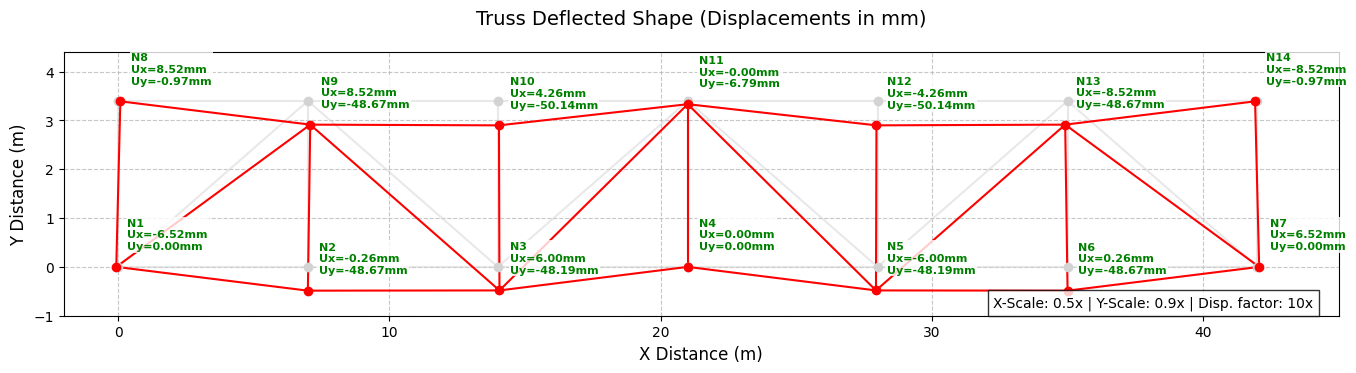

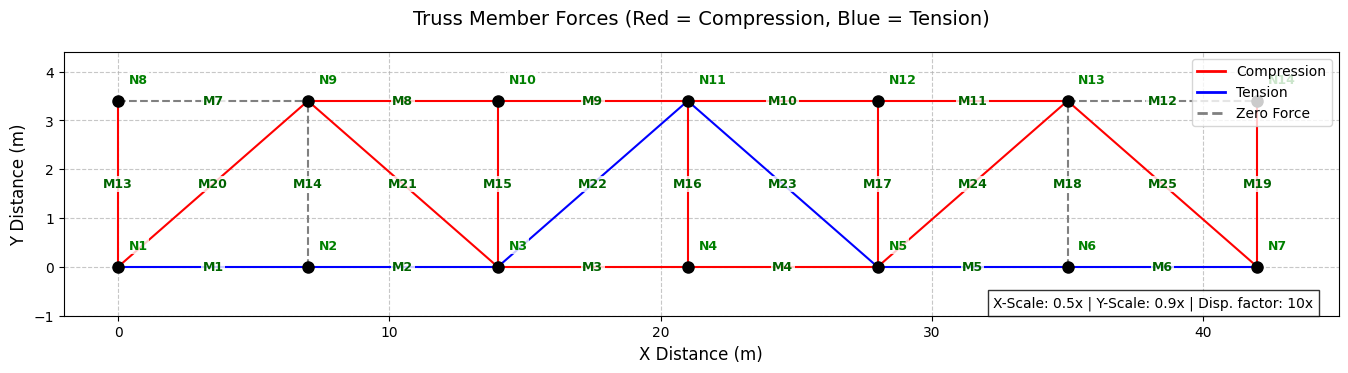

In [119]:
from openseespy.opensees import *
import math
import numpy as np
import matplotlib.pyplot as plt

# Constants
E = 210*10**9  # (N/m^2)

outer_dim = 0.6  # mm 
inner_dim = 0.016  # mm 
A = outer_dim**2 - (outer_dim - (2 * inner_dim))**2 

# Apply specified loads

dead_load_node = 2000000.0  # N (dead load per node)
live_load_node = 1200000.0  # N (live load per node)
gamma_G = 1.35           # Dead load factor
gamma_Q = 1.5            # Live load factor

# Calculate factored load per node
F = gamma_G * dead_load_node + gamma_Q * live_load_node  # 4500 N per node


# Nodal coordinates [x, y]
nodes = np.array([
    [0, 0], [7, 0], [14, 0], [21, 0], [28, 0], [35, 0], [42, 0],
    [0, 3.4], [7, 3.4], [14, 3.4], [21, 3.4], [28, 3.4], [35, 3.4], [42, 3.4]
])

# Members [node_i, node_j]
members = np.array([
    [1,2], [2,3], [3,4], [4,5], [5,6], [6,7],
    [8,9], [9,10], [10,11], [11,12], [12,13], [13,14],
    [1,8], [2,9], [3,10], [4,11], [5,12], [6,13], [7,14],
    [1,9], [9,3], [3,11], [11,5], [5,13], [13,7]
])

# Create figure with adjustable size
fig = plt.figure(figsize=(PLOT_WIDTH, PLOT_HEIGHT))
axes = fig.add_axes([0.1, 0.1, 0.85, 0.85])  # [left, bottom, width, height]

# Apply axis scaling
axes.set_xlim(X_RANGE[0], X_RANGE[1])
axes.set_ylim(Y_RANGE[0], Y_RANGE[1])
axes.set_aspect(Y_SCALE/X_SCALE)  # Controls aspect ratio

# Plot members with numbers
for mbr_num, mbr in enumerate(members, start=1):
    node_i, node_j = mbr[0]-1, mbr[1]-1  # Convert to 0-based index
    ix, iy = nodes[node_i]
    jx, jy = nodes[node_j]
    
    # Plot member line
    line = axes.plot([ix, jx], [iy, jy], 'b-', linewidth=1.5)[0]
    
    # Add member number (with background for readability)
    mid_x, mid_y = (ix+jx)/2, (iy+jy)/2
    axes.text(mid_x, mid_y, f'M{mbr_num}', 
              color='red', fontsize=9, weight='bold',
              ha='center', va='center',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Plot nodes with numbers
for node_num, (x, y) in enumerate(nodes, start=1):
    axes.plot(x, y, 'bo', markersize=8)
    axes.text(x + 0.8*X_SCALE, y + 0.4*Y_SCALE, f'N{node_num}',
             color='green', fontsize=9, weight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Customize grid and labels
axes.grid(True, linestyle='--', alpha=0.7)
axes.set_xlabel('X Distance (m)', fontsize=12)
axes.set_ylabel('Y Distance (m)', fontsize=12)
axes.set_title('Truss Structure Analysis', fontsize=14, pad=20)

# Add scale indicators
scale_text = f"X-Scale: {X_SCALE}x | Y-Scale: {Y_SCALE}x"
axes.text(0.98, 0.02, scale_text, transform=axes.transAxes,
          ha='right', va='bottom', fontsize=10,
          bbox=dict(facecolor='white', alpha=0.8))

# ========== USER-CONFIGURABLE PARAMETERS ==========
PLOT_WIDTH = 15  # Overall figure width (inches)
PLOT_HEIGHT = 6  # Overall figure height (inches)
X_RANGE = [-2, 45]  # [min, max] x-axis range
Y_RANGE = [-1.0, 4.4]   # [min, max] y-axis range
X_SCALE = 0.5       # Scaling factor for x-axis (1.0 = normal)
Y_SCALE = 0.9       # Scaling factor for y-axis (1.0 = normal)
# ==================================================



plt.show()


# Remove any existing model
wipe()

# Set the modelbuilder - 2 dimensions and 2 degrees of freedom per node
model('basic', '-ndm', 2, '-ndf', 2)

for i, n in enumerate(nodes):
    node(i+1, float(n[0]), float(n[1]))
    print(f'Node {i+1} defined')

#Define a new uniaxial material (Elastic matID E)
uniaxialMaterial("Elastic", 1, E)
#Define each element
for i, mbr in enumerate(members):
    element("Truss", i+1, int(mbr[0]), int(mbr[1]), A, 1)   
    print(f'Element {i+1} defined')

    # Set boundary condition
fix(1, 0, 1)  # Keep Y-constraint at node 1
fix(7, 0, 1)  # Keep Y-constraint at node 7
fix(4, 1, 1)  # Change to full pin at node 4 (X and Y)

print('\033[1m\033[95m\n************************************')
print('*** BOUNDARY CONDITIONS FIXED ***')
print('************************************\033[0m\n')



# Minimal valid load application
timeSeries("Constant", 1)  # Required time series
pattern("Plain", 1, 1)     # Required load pattern

load(8, 0.0, -F/2)
load(9, 0.0, -F)
load(10, 0.0, -F) 
load(11, 0.0, -F)
load(12, 0.0, -F)
load(13, 0.0, -F)
load(14, 0.0, -F/2)


print('\033[1m\033[95m\n************************************')
print('*** LOAD APPLIED ***')
print('************************************\033[0m\n')



# create SOE
system("BandSPD")

# create DOF number
numberer("RCM")

# create constraint handler
constraints("Plain")

# create integrator
integrator("LoadControl", 1.0)

# create algorithm
algorithm("Linear")

# create analysis object
analysis("Static")

# perform the analysis
analyze(1)

print("")
print("NODAL DISPLACEMENTS") 
for i, n in enumerate(nodes):     
    ux = round(nodeDisp(i+1, 1),5) #Horizontal nodal displacement
    uy = round(nodeDisp(i+1, 2),5) #Vertical nodal displacement
    print(f'Node {i+1}: Ux = {ux*1000} mm, Uy = {uy*1000} mm')

    print('\033[1m\033[95m\n************************************')
print('*** Analysis Done Succesfully ***')
print('************************************\033[0m\n')


print("MEMBER FORCES") 
mbrForces = np.array([])
for i, mbr in enumerate(members): 
    axialForce = round(basicForce(i+1)[0]/1000,2)
    mbrForces = np.append(mbrForces,axialForce) #Store axial loads    
    print(f'Force in member {i+1} (nodes {mbr[0]} to {mbr[1]}) is {axialForce} N')  


    # Create figure with identical parameters to the original plot
fig = plt.figure(figsize=(PLOT_WIDTH, PLOT_HEIGHT))
axes = fig.add_axes([0.1, 0.1, 0.85, 0.85])  # Identical layout

# Apply identical axis scaling
axes.set_xlim(X_RANGE[0], X_RANGE[1])
axes.set_ylim(Y_RANGE[0], Y_RANGE[1])
axes.set_aspect(Y_SCALE/X_SCALE)  # Same aspect ratio

# Displacement magnification factor
xFac = 10  # Adjust this value as needed for visualization

# Plot undeformed members (light gray)
for mbr_num, mbr in enumerate(members, start=1):
    node_i, node_j = mbr[0]-1, mbr[1]-1
    ix, iy = nodes[node_i]
    jx, jy = nodes[node_j]
    axes.plot([ix, jx], [iy, jy], 'lightgray', linewidth=1.5, alpha=0.5)

# Plot deformed members (red)
for mbr_num, mbr in enumerate(members, start=1):
    node_i = int(mbr[0])
    node_j = int(mbr[1])
    
    ix, iy = nodes[node_i-1]
    jx, jy = nodes[node_j-1]
    
    ux_i, uy_i = nodeDisp(node_i, 1), nodeDisp(node_i, 2)
    ux_j, uy_j = nodeDisp(node_j, 1), nodeDisp(node_j, 2)
    
    # Plot deformed member
    axes.plot([ix + ux_i*xFac, jx + ux_j*xFac],
              [iy + uy_i*xFac, jy + uy_j*xFac], 
              'r-', linewidth=1.5)

# Plot nodes and deflection values
for node_num, (x, y) in enumerate(nodes, start=1):
    ux, uy = nodeDisp(node_num, 1), nodeDisp(node_num, 2)
    
    # Original position (light gray)
    axes.plot(x, y, 'o', color='lightgray', markersize=6)
    
    # Deformed position (red)
    axes.plot(x + ux*xFac, y + uy*xFac, 'ro', markersize=6)
    
    # Node number and deflection values
    def_text = f'N{node_num}\nUx={ux*1000:.2f}mm\nUy={uy*1000:.2f}mm'
    axes.text(x + ux*xFac + 0.8*X_SCALE, 
              y + uy*xFac + 0.4*Y_SCALE, 
              def_text,
              color='green', fontsize=8, weight='bold',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Customization matching original plot
axes.grid(True, linestyle='--', alpha=0.7)
axes.set_xlabel('X Distance (m)', fontsize=12)
axes.set_ylabel('Y Distance (m)', fontsize=12)
axes.set_title(f'Truss Deflected Shape (Displacements in mm)', fontsize=14, pad=20)

# Scale indicator
scale_text = f"X-Scale: {X_SCALE}x | Y-Scale: {Y_SCALE}x | Disp. factor: {xFac}x"
axes.text(0.98, 0.02, scale_text, transform=axes.transAxes,
          ha='right', va='bottom', fontsize=10,
          bbox=dict(facecolor='white', alpha=0.8))

plt.show()
      
# Create figure with same parameters as original plot
fig = plt.figure(figsize=(PLOT_WIDTH, PLOT_HEIGHT))
axes = fig.add_axes([0.1, 0.1, 0.85, 0.85])  # Same layout as original plots

# Apply same axis scaling
axes.set_xlim(X_RANGE[0], X_RANGE[1])
axes.set_ylim(Y_RANGE[0], Y_RANGE[1])
axes.set_aspect(Y_SCALE/X_SCALE)  # Same aspect ratio control

# Plot members with force visualization
for mbr_num, mbr in enumerate(members):
    node_i, node_j = mbr[0]-1, mbr[1]-1  # Convert to 0-based index
    ix, iy = nodes[node_i]
    jx, jy = nodes[node_j]
    
    force = mbrForces[mbr_num]
    
    # Determine line style based on force
    if abs(force) < 0.001:
        line = axes.plot([ix, jx], [iy, jy], 'gray', linestyle='--', linewidth=1.5)[0]  # Zero force
    elif force > 0:
        line = axes.plot([ix, jx], [iy, jy], 'blue', linewidth=1.5)[0]  # Tension
    else:
        line = axes.plot([ix, jx], [iy, jy], 'red', linewidth=1.5)[0]  # Compression
    
    # Add member number (same style as original plot)
    mid_x, mid_y = (ix+jx)/2, (iy+jy)/2
    axes.text(mid_x, mid_y, f'M{mbr_num+1}', 
              color='darkgreen', fontsize=9, weight='bold',
              ha='center', va='center',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Plot nodes with numbers (same style as original plot)
for node_num, (x, y) in enumerate(nodes, start=1):
    axes.plot(x, y, 'ko', markersize=8)
    axes.text(x + 0.8*X_SCALE, y + 0.4*Y_SCALE, f'N{node_num}',
             color='green', fontsize=9, weight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Customize grid and labels (same as original plot)
axes.grid(True, linestyle='--', alpha=0.7)
axes.set_xlabel('X Distance (m)', fontsize=12)
axes.set_ylabel('Y Distance (m)', fontsize=12)
axes.set_title('Truss Member Forces (Red = Compression, Blue = Tension)', fontsize=14, pad=20)

# Add legend for force visualization
legend_elements = [
    plt.Line2D([0], [0], color='red', lw=2, label='Compression'),
    plt.Line2D([0], [0], color='blue', lw=2, label='Tension'),
    plt.Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Zero Force')
]
axes.legend(handles=legend_elements, loc='upper right')

# Add scale indicators (same as original plot)
#scale_text = f"X-Scale: {X_SCALE}x | Y-Scale: {Y_SCALE}x"
axes.text(0.98, 0.02, scale_text, transform=axes.transAxes,
          ha='right', va='bottom', fontsize=10,
          bbox=dict(facecolor='white', alpha=0.8))

#plt.savefig('member_forces_plot.png', bbox_inches='tight', dpi=300)
plt.show()